In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


The dataset was loaded successfully using Pandas. It contains student academic performance information.

In [37]:
df.head(5)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [38]:
df.tail(5)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [39]:
df.sample(5)

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
699,male,group C,high school,free/reduced,none,66,66,59
309,female,group D,high school,free/reduced,none,49,57,52
697,female,group A,bachelor's degree,standard,none,59,72,70
615,female,group C,high school,standard,none,60,68,72
894,female,group E,associate's degree,standard,none,59,62,69


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

The dataset contains 1,000 rows and 8 columns. It includes 5 categorical columns and 3 numerical columns. The numerical columns are math score, reading score, and writing score. All columns contain 1,000 non-null values.

In [7]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [40]:
(df.isnull().sum()/len(df))*100

gender                         0.0
race/ethnicity                 0.0
parental_level_of_education    0.0
lunch                          0.0
test_preparation_course        0.0
math_score                     0.0
reading_score                  0.0
writing_score                  0.0
dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

The dataset was checked for missing values and duplicate rows. No missing values and no duplicate rows were found. Therefore, no rows were removed during the cleaning process.


In [11]:
df.select_dtypes(include="number").columns

Index(['math score', 'reading score', 'writing score'], dtype='str')

In [12]:
df.select_dtypes(include="object").columns

C:\Users\Sanjhira\AppData\Local\Temp\ipykernel_6340\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='str')

In [13]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [14]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.columns

Index(['gender', 'race/ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

In [15]:
df.shape


(1000, 8)

In [19]:
df[["math_score", "reading_score", "writing_score"]].min()

math_score        0
reading_score    17
writing_score    10
dtype: int64

In [20]:
df[["math_score", "reading_score", "writing_score"]].max()

math_score       100
reading_score    100
writing_score    100
dtype: int64

In [21]:
df[["math_score", "reading_score", "writing_score"]].std()

math_score       15.163080
reading_score    14.600192
writing_score    15.195657
dtype: float64

In [22]:
df[["math_score", "reading_score", "writing_score"]].var()

math_score       229.918998
reading_score    213.165605
writing_score    230.907992
dtype: float64

In [23]:
df[["math_score", "reading_score", "writing_score"]].corr()

,math_score,reading_score,writing_score
math_score,1.000000,0.817580,0.802642
reading_score,0.817580,1.000000,0.954598
writing_score,0.802642,0.954598,1.000000


: Reading has the highest average score at 69.17, followed by Writing at 68.05 and Math at 66.09. The standard deviation values show variation in students' scores.

# Data visualization

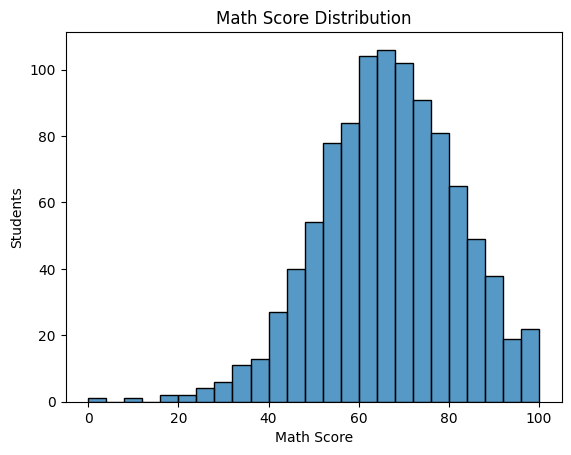

In [49]:
#Histogram
sns.histplot(df["math_score"])
plt.title("Math Score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Students")
plt.show()

The histogram shows the distribution of students' Math scores. Most scores are concentrated around the middle range

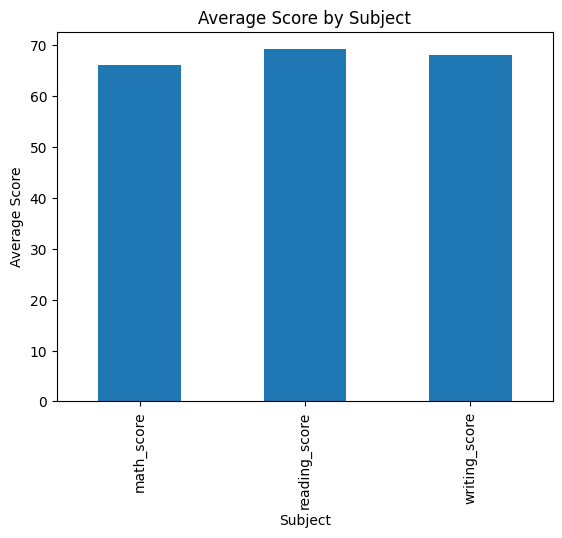

In [50]:
#Bar Chart
df[["math_score", "reading_score", "writing_score"]].mean().plot(kind="bar")
plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.show()

The bar chart compares the average scores of Math, Reading, and Writing. Reading has the highest average score.

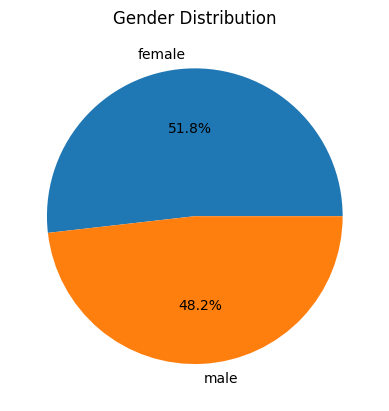

In [51]:
#pie chart
df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

The pie chart shows the proportion of male and female students in the dataset.

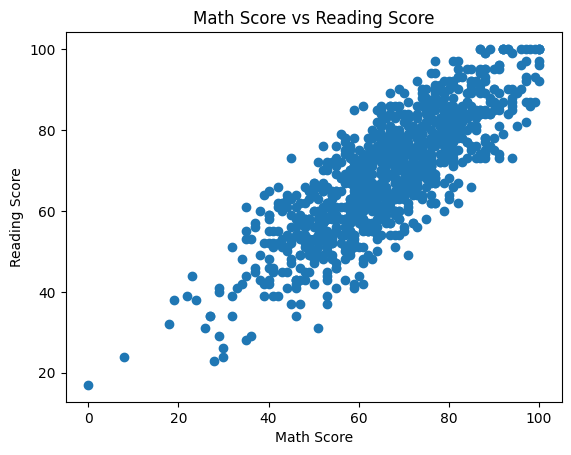

In [52]:
#Scatter Plot
plt.scatter(df["math_score"], df["reading_score"])
plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()


The scatter plot shows a positive relationship between Math and Reading scores. Students with higher Math scores generally tend to have higher Reading scores.

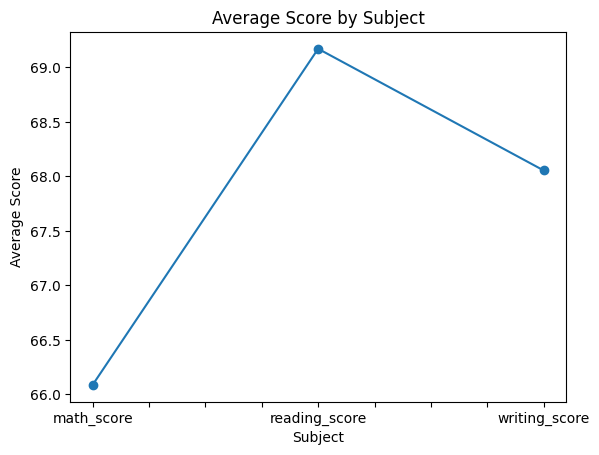

In [53]:
# line chart
df[["math_score", "reading_score", "writing_score"]].mean().plot(marker="o")
plt.title("Average Score by Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.show()

The pie chart shows the proportion of male and female students in the dataset.

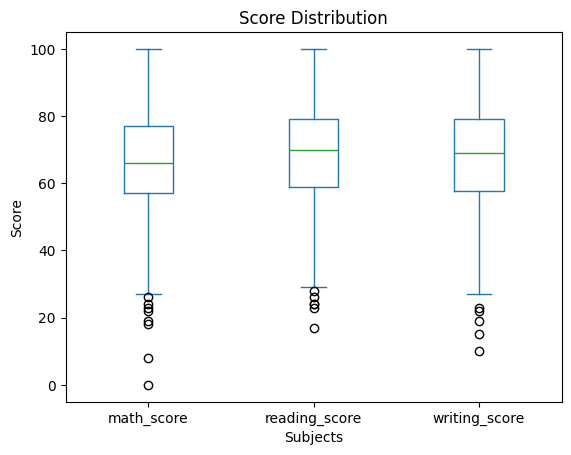

In [54]:
# Box plot
df[["math_score", "reading_score", "writing_score"]].plot(kind="box")
plt.title("Score Distribution")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.show()

The box plot shows the spread and distribution of scores and helps identify unusual values.

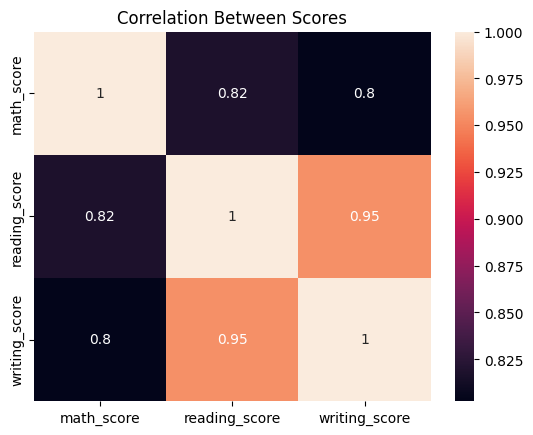

In [55]:
# Correlation heatmap 
sns.heatmap(df[["math_score", "reading_score", "writing_score"]].corr(), annot=True)
plt.title("Correlation Between Scores")
plt.show()

The heatmap shows strong positive correlations between all three subjects. The strongest relationship is between Reading and Writing.

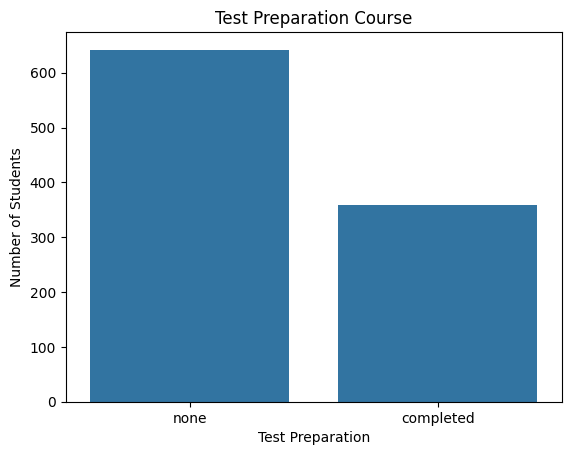

In [56]:
# Count Plot
sns.countplot(data=df, x="test_preparation_course")
plt.title("Test Preparation Course")
plt.xlabel("Test Preparation")
plt.ylabel("Number of Students")
plt.show()

The count plot compares students who completed the test preparation course with those who did not.

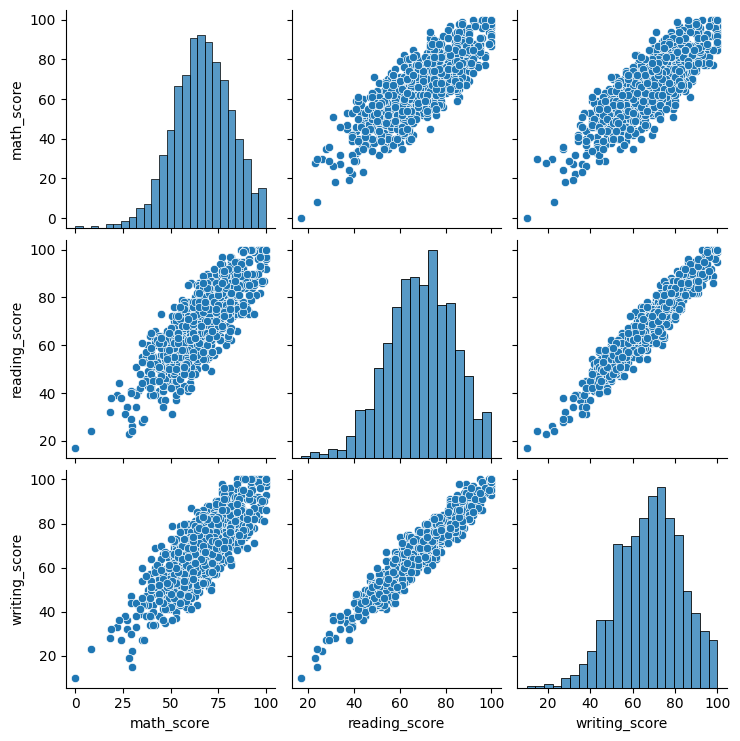

In [57]:
# pair plot
sns.pairplot(df[["math_score", "reading_score", "writing_score"]])
plt.show()

The pair plot shows the relationships and distributions among Math, Reading, and Writing scores.

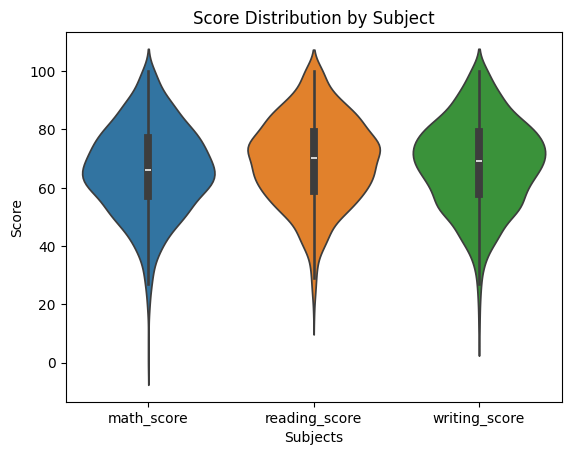

In [58]:
#Violin Plot
sns.violinplot(data=df[["math_score", "reading_score", "writing_score"]])
plt.title("Score Distribution by Subject")
plt.xlabel("Subjects")
plt.ylabel("Score")
plt.show()

The violin plot shows the distribution and spread of scores for the three subjects.

# Insights & Findings

In [59]:
df.groupby("gender")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [60]:
df.groupby("test_preparation_course")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
test_preparation_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [61]:
df.groupby("lunch")[["math_score","reading_score","writing_score"]].mean()

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [62]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

In [63]:
df[["math_score","reading_score","writing_score"]].max()

math_score       100
reading_score    100
writing_score    100
dtype: int64

In [64]:
df[["math_score","reading_score","writing_score"]].min()

math_score        0
reading_score    17
writing_score    10
dtype: int64

In [65]:
df[["math_score","reading_score","writing_score"]].std()

math_score       15.163080
reading_score    14.600192
writing_score    15.195657
dtype: float64

## Conclusion

This project analyzed a student performance dataset containing 1,000 records and 8 columns. The data was explored and checked for missing values and duplicate records. No missing values or duplicate rows were found. Statistical analysis was performed using mean, median, minimum, maximum, standard deviation, and variance to understand students' performance in Math, Reading, and Writing.

The analysis and visualizations showed that Reading and Writing scores have a strong positive relationship. Students who completed the test preparation course generally achieved higher average scores in all three subjects. The analysis also showed differences in performance based on gender and lunch type. Overall, this project helped in understanding how Python, Pandas, Matplotlib, and Seaborn can be used for data analysis, visualization, and extracting meaningful insights from a real-world dataset.
